# Load packages

In [1]:
from pybootnet import *

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import infomap
from infomap import Options #for result.modules()
import numpy as np
import igraph as ig
import leidenalg
from sklearn import metrics 
import itertools
from networkx.algorithms.community import girvan_newman, modularity

# T5 

### Read Data

In [4]:
clean_T5_data = pd.read_csv('t5_16s_clean.csv')
t5meta_data = pd.read_csv('T5_16s_clr.csv')
t5meta_data = t5meta_data[['OTUID', 'Category']]
t5meta_data['OTUID'] = t5meta_data['OTUID'].str.replace('.', '_')
combined_t5 = pd.merge(t5meta_data, clean_T5_data, on='OTUID', how='right')

### Separate Treatment Groups

In [5]:
placebot5 = combined_t5[combined_t5['Category'] == 'Placebo']
letrozolet5 = combined_t5[combined_t5['Category'] == 'Letrozole']
co_placebot5 = combined_t5[combined_t5['Category'] == 'Co-P']
co_letrozolet5 = combined_t5[combined_t5['Category'] == 'Co-L']

## Placebo

### Bootstrapping and Correlation Network

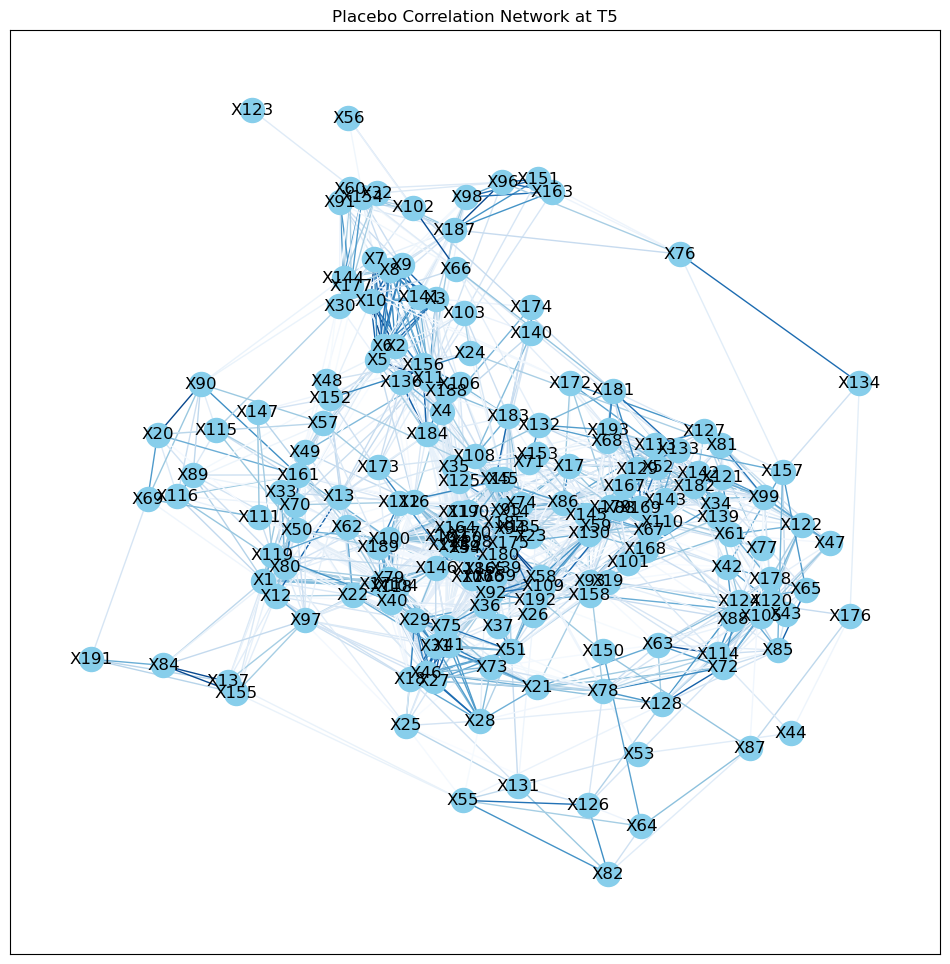

In [6]:
# bootstrap replicates of placebo group at time 5
placebo_boot_t5 = bootstrap_replicates(placebot5, 500)

# Correlation matrix constructed from bootstrap replicates
placebo_corr_t5 = correlation_matrix(placebo_boot_t5)

# Network graph of positive correlations placebo group time 5
t5out = build_positive_network(placebo_corr_t5, 0.6, title="Placebo Correlation Network at T5")

### Louvain Community Detection

https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.community.louvain.louvain_communities.html

In [7]:
#find the best partition using NetworkX louvain_communities
louvain_c2 = nx.community.louvain_communities(t5out, weight="weight", seed=42)

#examine output
print(louvain_c2)

[{'X22', 'X48', 'X119', 'X104', 'X24', 'X50', 'X189', 'X115', 'X171', 'X118', 'X45', 'X31', 'X112', 'X1', 'X75', 'X146', 'X26', 'X12', 'X51', 'X57', 'X33', 'X89', 'X111', 'X90', 'X41', 'X191', 'X147', 'X18', 'X21', 'X28', 'X116', 'X152', 'X137', 'X80', 'X97', 'X29', 'X161', 'X103', 'X62', 'X70', 'X84', 'X40', 'X25', 'X73', 'X46', 'X155', 'X69', 'X49', 'X20', 'X27', 'X79'}, {'X187', 'X9', 'X60', 'X98', 'X11', 'X2', 'X102', 'X106', 'X123', 'X141', 'X163', 'X140', 'X76', 'X188', 'X10', 'X66', 'X3', 'X134', 'X156', 'X13', 'X108', 'X154', 'X6', 'X177', 'X173', 'X8', 'X151', 'X183', 'X184', 'X56', 'X136', 'X96', 'X144', 'X4', 'X5', 'X32', 'X174', 'X7', 'X30', 'X91'}, {'X100', 'X158', 'X58', 'X192', 'X37', 'X107', 'X175', 'X138', 'X92', 'X170', 'X117', 'X15', 'X125', 'X54', 'X94', 'X164', 'X162', 'X165', 'X14', 'X86', 'X166', 'X185', 'X19', 'X180', 'X23', 'X36', 'X190', 'X160', 'X16', 'X148', 'X95', 'X135', 'X159', 'X186', 'X39', 'X74', 'X109', 'X149'}, {'X150', 'X53', 'X87', 'X64', 'X176', '

In [8]:
#create a dictionary where node is key and value is community index label
louvain_clusters = {}
for community, nodes in enumerate(louvain_c2):
    for node in nodes:
        louvain_clusters[node] = community

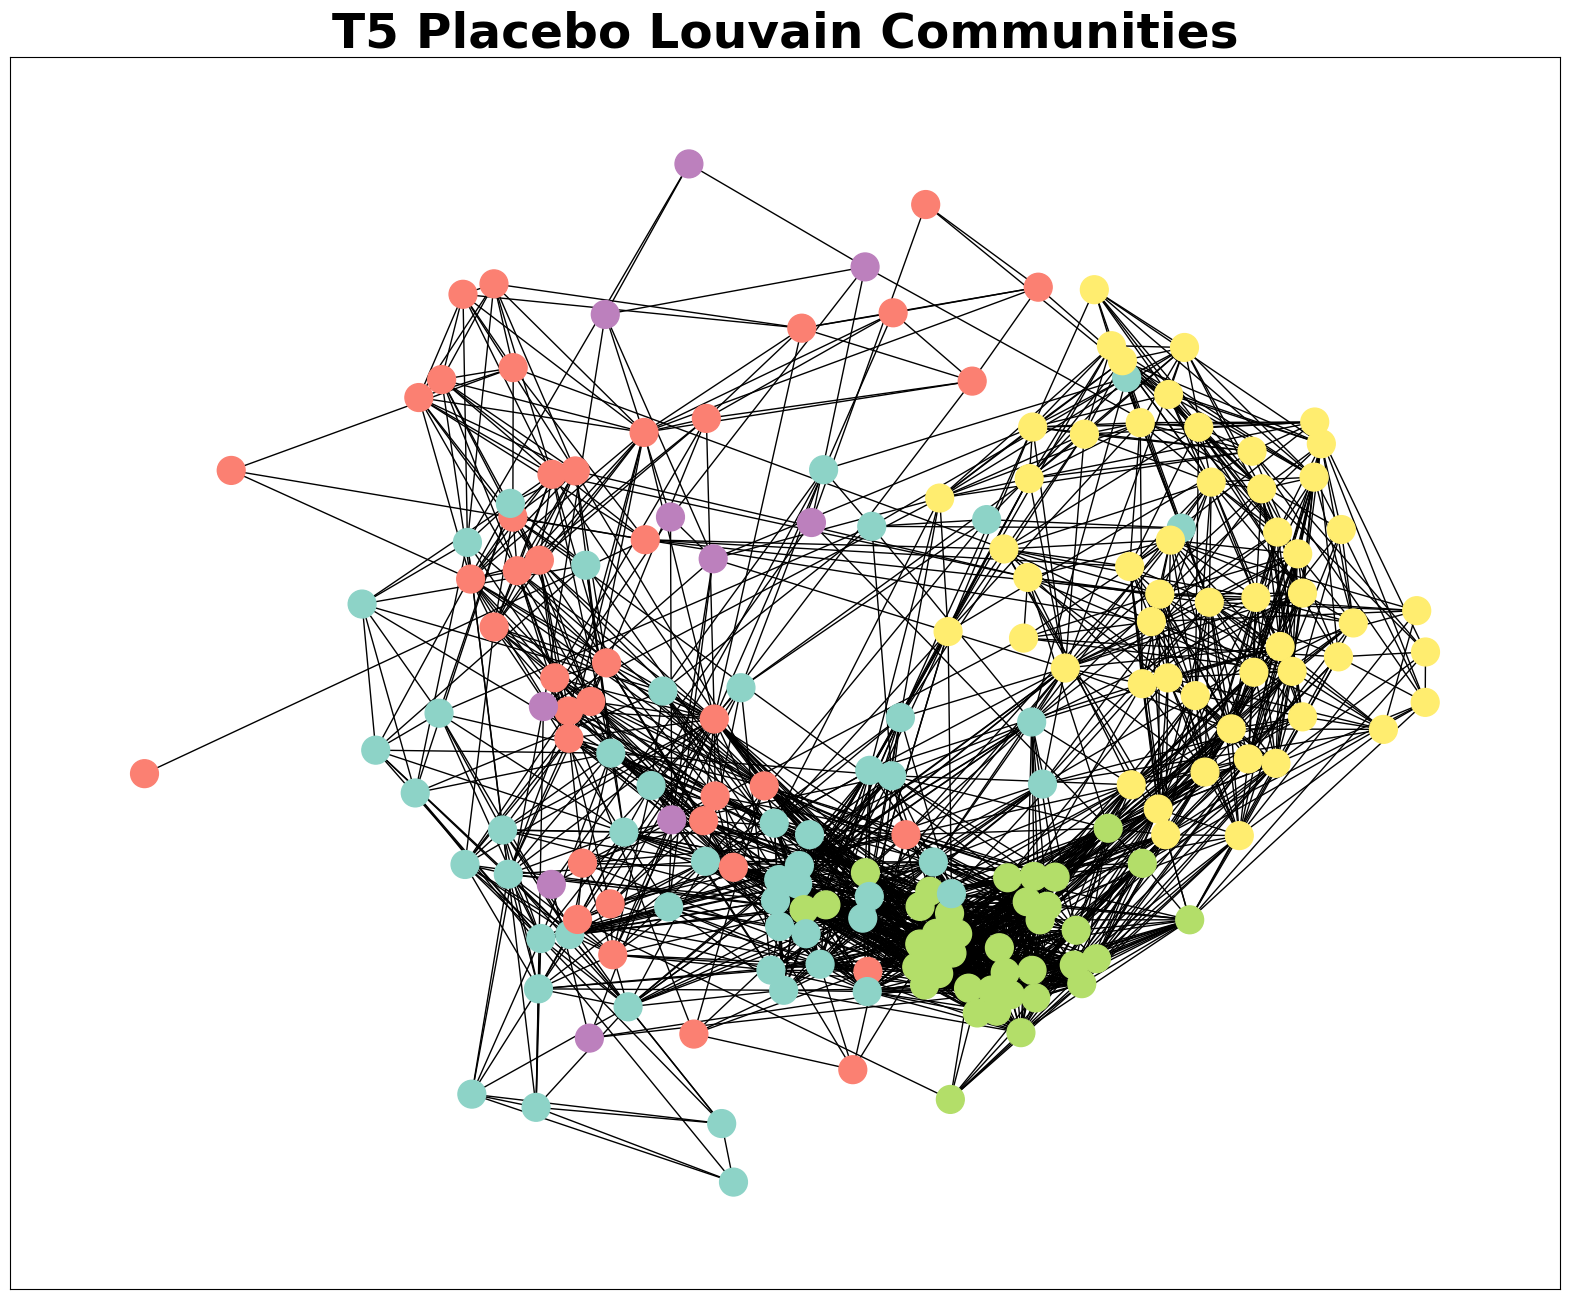

In [9]:
#draw louvain plot
#assign color to nodes based on louvain communities
node_colors_louvain = [louvain_clusters[node] for node in t5out.nodes()]

#force directed layout, seed for plot reproducibility
pos = nx.spring_layout(t5out, seed=42, k=0.6, iterations=100)

#add weighted edges**********

#draw network
plt.figure(figsize=(20, 16))
nx.draw_networkx(
    t5out, 
    node_color=node_colors_louvain,
    cmap=plt.cm.Set3, #set colormap 
    pos=pos,
    with_labels=False,
    font_size=12,
    node_size=400,
    #width=widths2 #add weighted edges
)
plt.title("T5 Placebo Louvain Communities", fontsize=35, fontweight="bold")
plt.show()

### Leiden Community Detection

##### leidenalg built on igraph https://leidenalg.readthedocs.io/en/stable/intro.html so converting NetworkX to igraph format needed, https://networkx.org/documentation/stable/auto_examples/external/plot_igraph.html, https://leidenalg.readthedocs.io/en/stable/intro.html, https://leidenalg.readthedocs.io/en/stable/reference.html#modularityvertexpartition, https://python.igraph.org/en/latest/api/igraph.Graph.html#from_networkx

#### Convert NetworkX graph to igraph

In [10]:
t5out_igraph = ig.Graph.from_networkx(t5out)

In [11]:
t5out_igraph.es.attribute_names()
t5out_igraph.es["weight"][:5]

[np.float64(0.6406783314893559),
 np.float64(0.7768004866952886),
 np.float64(0.7053268481267246),
 np.float64(0.7768004866952886),
 np.float64(0.6472737454036073)]

In [12]:
# leiden community detection algorithm 
leiden_partition = leidenalg.find_partition(
    t5out_igraph,
    leidenalg.RBConfigurationVertexPartition, #objective function
    resolution_parameter=1.0,
    #leidenalg.ModularityVertexPartition, #objective function
    #leidenalg.CPMVertexPartition,
    #resolution_parameter = 0.05,
    seed=42 #fixed seed
)


In [13]:
print(leiden_partition)

Clustering with 192 elements and 5 clusters
[0] 89, 90, 95, 96, 97, 98, 99, 100, 101, 103, 119, 120, 121, 127, 128, 129,
    130, 131, 132, 134, 135, 140, 143, 144, 145, 146, 152, 153, 154, 155, 156,
    157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 168, 171, 172, 173, 174,
    175, 178, 179, 180, 184, 185, 191
[1] 0, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21,
    66, 71, 72, 73, 74, 75, 93, 94, 102, 105, 106, 107, 108, 109, 111, 112,
    113, 114, 115, 122, 123, 124, 125, 126, 133, 136, 137, 138, 139, 188
[2] 1, 26, 28, 41, 42, 43, 45, 46, 47, 48, 49, 50, 51, 54, 55, 56, 57, 58, 59,
    77, 78, 79, 80, 81, 82, 83, 85, 86, 87, 88, 91, 92, 110, 116, 118, 148,
    167, 169, 170
[3] 22, 23, 24, 25, 27, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 44,
    52, 53, 60, 61, 62, 63, 64, 65, 67, 68, 69, 70, 76, 84, 147, 149, 150,
    151, 187, 189
[4] 104, 117, 141, 142, 176, 177, 181, 182, 183, 186, 190


In [14]:
#create a dictionary where node is key and value is community index label https://python.igraph.org/en/stable/tutorial.html
leiden_clusters = {}

for community, vertex_indices in enumerate(leiden_partition):
    for vertex_index in vertex_indices:
        node_label = t5out_igraph.vs[vertex_index]["_nx_name"]
        leiden_clusters[node_label] = community

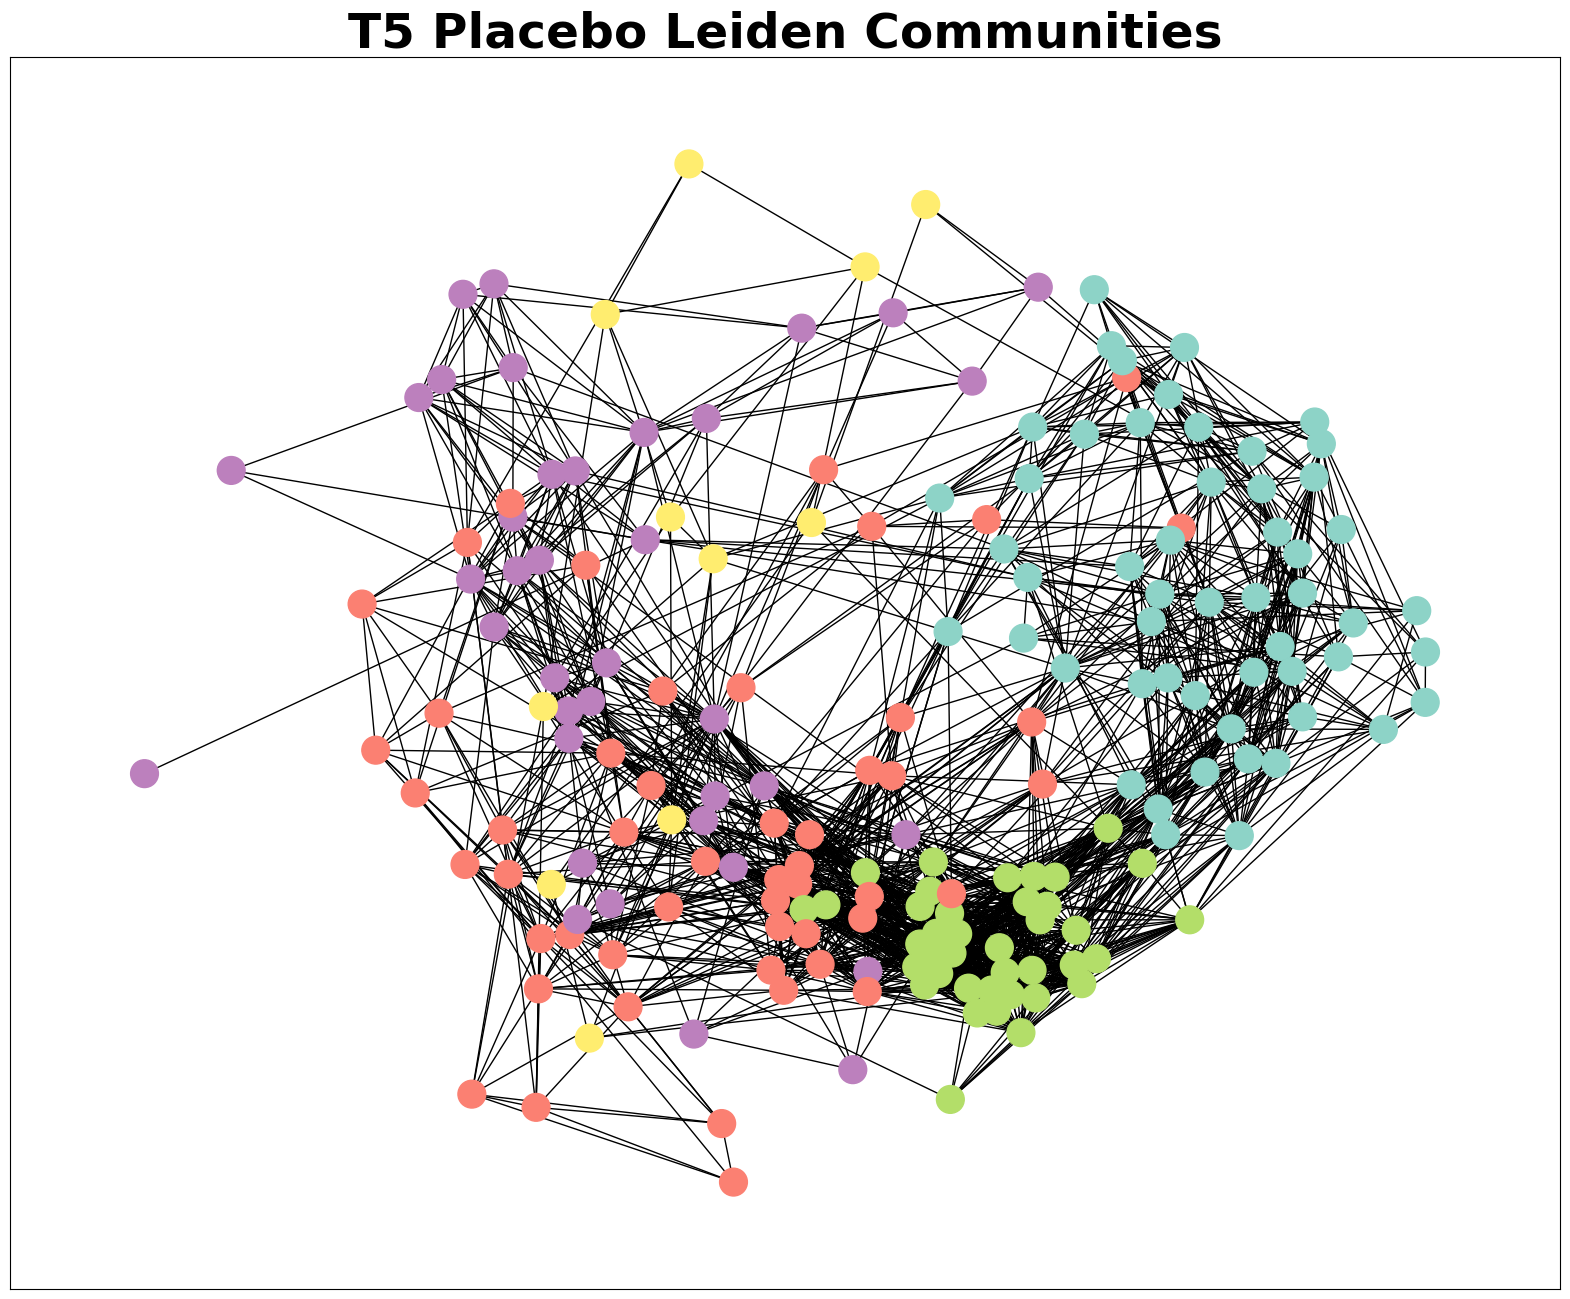

In [15]:
#Draw Leiden plot
#assign color to nodes based on leiden communities
node_colors_leiden = [leiden_clusters[node] for node in t5out.nodes()]

#draw network
plt.figure(figsize=(20, 16))
nx.draw_networkx(
    t5out, 
    node_color=node_colors_leiden,
    cmap=plt.cm.Set3, #set colormap 
    pos=pos,
    with_labels=False,
    font_size=12,
    node_size=400,
    #width=widths2 #add weighted edges
)
plt.title("T5 Placebo Leiden Communities", fontsize=35, fontweight="bold")
plt.show()

### Girvan-Newman Algorithm

https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.community.centrality.girvan_newman.html

### Walktrap Algorithm 

##### https://python.igraph.org/en/latest/api/igraph.community.html?private=1#_community_walktrap, &https://python.igraph.org/en/latest/api/igraph.VertexDendrogram.html#as_clusterin, https://python.igraph.org/en/latest/api/igraph.Graph.html#from_networkxg

In [16]:
# walktrap community detection
wt = t5out_igraph.community_walktrap(weights=t5out_igraph.es["weight"], steps=4)  # steps choice, 4 is default
walktrap_partition = wt.as_clustering()  # igraph picks cut/flat partition that maximizes modularity


In [17]:
print(walktrap_partition)

Clustering with 192 elements and 13 clusters
[ 0] 0, 1, 2, 4, 5, 8, 9, 10, 11, 12, 13, 14, 16, 17, 18, 21, 66, 71, 72, 73,
     74, 75, 93, 94, 102, 105, 106, 107, 108, 109, 111, 112, 113, 114, 115,
     123, 131, 132
[ 1] 3, 15, 20, 122, 124, 125, 126
[ 2] 6, 7, 19, 188
[ 3] 22, 23, 24, 25, 27, 29, 31, 32, 33, 34, 35, 36, 37, 38, 39, 52, 60, 61,
     69, 76, 84
[ 4] 26, 28, 41, 42, 43, 45, 46, 47, 48, 49, 50, 51, 54, 55, 56, 57, 58, 59,
     77, 78, 79, 80, 81, 82, 83, 85, 86, 87, 88, 92, 110, 116, 118, 148, 167,
     169, 170
[ 5] 30, 40, 67, 68, 70, 189
[ 6] 44, 53, 62, 63, 64, 65, 147, 149, 150, 151
[ 7] 89, 90, 91, 95, 96, 97, 98, 99, 100, 101, 103, 134, 135, 140, 143, 144,
     145, 146, 152, 154, 156, 157, 159, 160, 161, 162, 163, 164, 165, 166,
     168, 171, 172, 184, 185, 191
[ 8] 104, 141, 142, 181, 182, 183, 186
[ 9] 117, 176, 177, 190
[10] 119, 120, 121, 127, 128, 129, 130, 153, 155, 158, 173, 174, 175, 178,
     179, 180
[11] 133, 136, 137, 138, 139
[12] 187


In [18]:
#create a dictionary where node is key and value is community index label
walktrap_clusters = {}

for community, vertex_indices in enumerate(walktrap_partition):
    for vertex_index in vertex_indices:
        node_label = t5out_igraph.vs[vertex_index]["_nx_name"]
        walktrap_clusters[node_label] = community

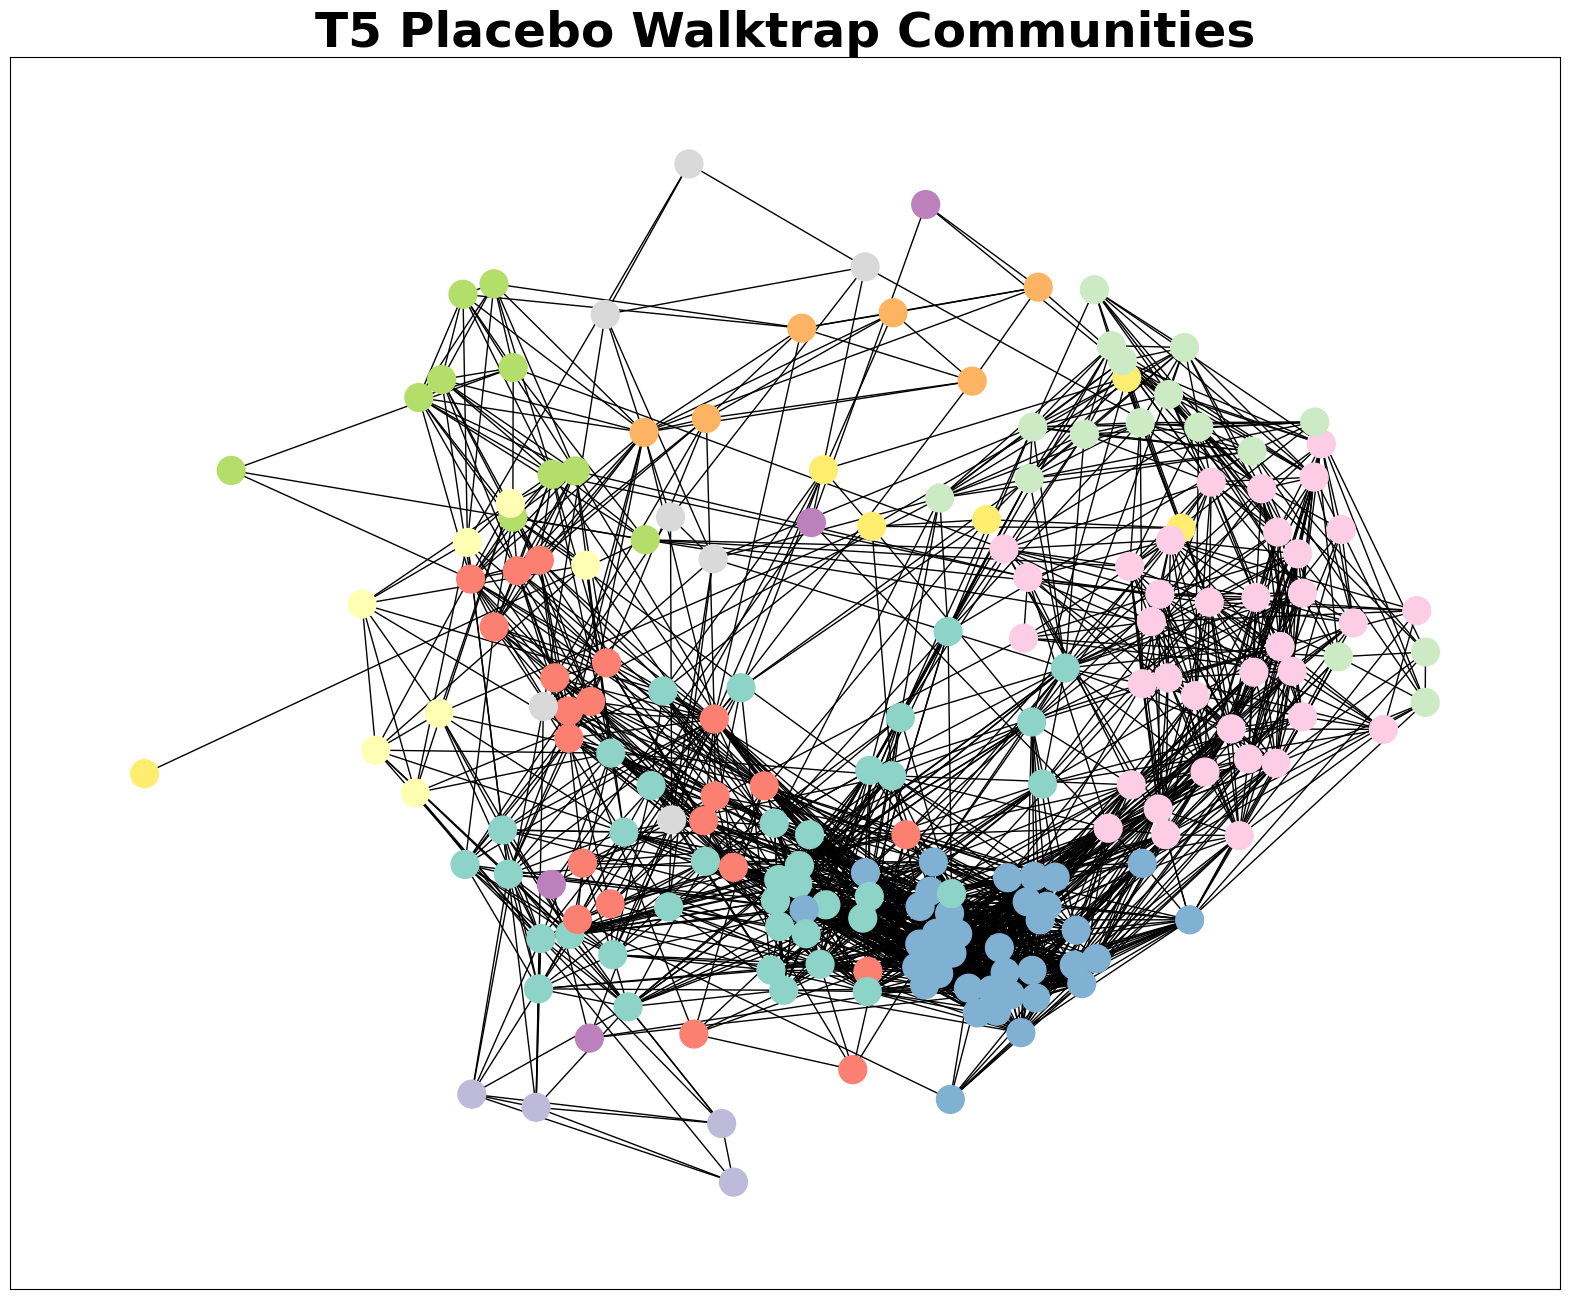

In [19]:
#Draw Walktrap plot

#assign color to nodes based on Walktrap communities
node_colors_walktrap = [walktrap_clusters[node] for node in t5out.nodes()]

#draw network
plt.figure(figsize=(20, 16))
nx.draw_networkx(
    t5out, 
    node_color=node_colors_walktrap,
    cmap=plt.cm.Set3, #set colormap 
    pos=pos,
    with_labels=False,
    font_size=12,
    node_size=400,
    #width=widths2 #add weighted edges
)
plt.title("T5 Placebo Walktrap Communities", fontsize=35, fontweight="bold")
plt.show()

### Infomap Algorithm

##### https://mapequation.org/infomap-python-docs/concepts/choosing-a-method.html

In [20]:
#Run infomap on G2, two_level for a flat parition, number of trials defaults to 1 unless set with num_trials
infomap_partition = infomap.run(t5out, two_level = True)
infomap_clusters = infomap_partition.modules()

In [21]:
#create dictionary for coloring nodes
infomap_labels = {}

for node_id, module_id in infomap_clusters.items(): #loop through key, value pairs
    node_name = infomap_partition.names[node_id] #access dictionary value by key using node_id as both dictionaries have those numbers in common
    infomap_labels[node_name] = module_id #add key/value pairs to new dictionary
       

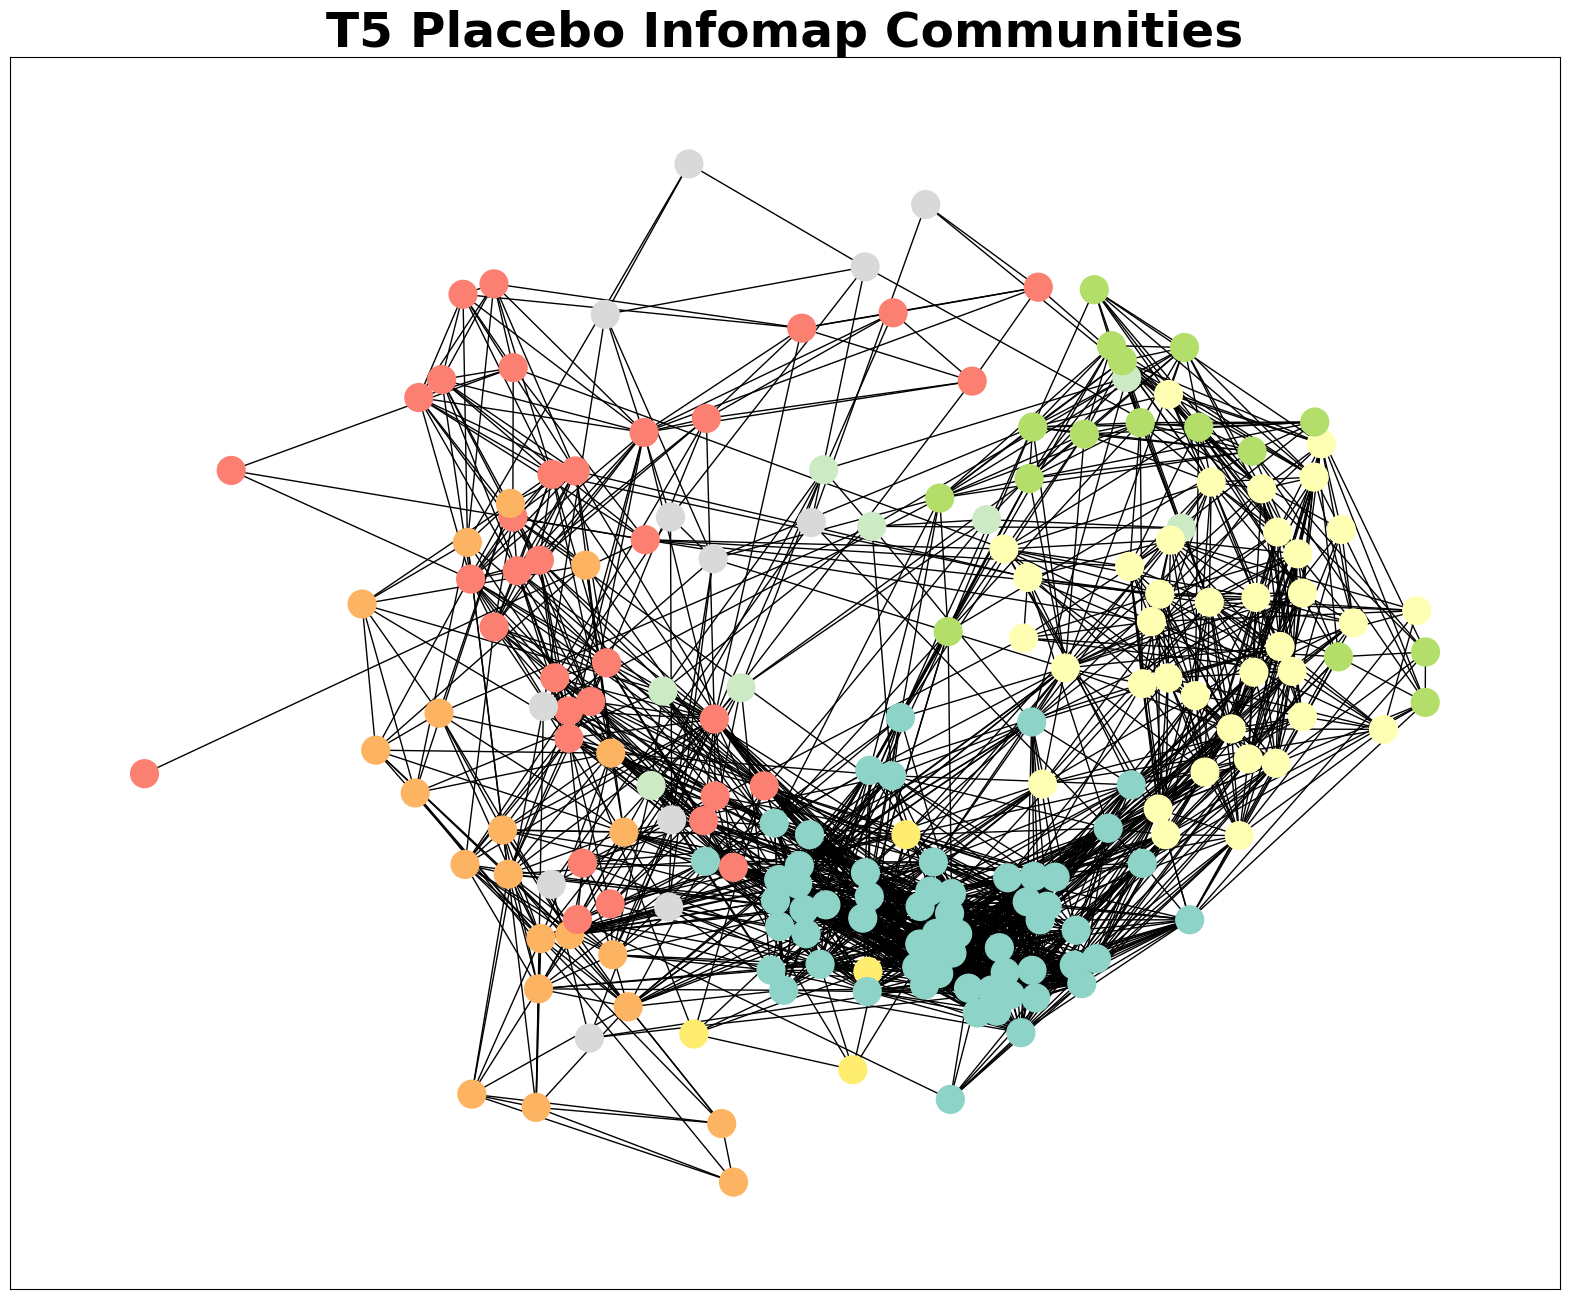

In [22]:
#Draw Infomap Plot

#assign color to nodes based on infomap_labels 
node_colors_infomap = [infomap_labels[node] for node in t5out.nodes()]

#draw network
plt.figure(figsize=(20, 16))
nx.draw_networkx(
    t5out, 
    node_color=node_colors_infomap,
    cmap=plt.cm.Set3, #set colormap 
    pos=pos,
    with_labels=False,
    font_size=12,
    node_size=400,
    #width=widths2 #add weighted edges
)
plt.title("T5 Placebo Infomap Communities", fontsize=35, fontweight="bold")
plt.show()

## Community Assignment Table

In [23]:
# create dataframe with labels for each method
df = pd.DataFrame({
    "taxon": list(t5out.nodes()), #create taxon column from node labels
    "louvain": [louvain_clusters[n] for n in t5out.nodes()], #for each node n look up louvain community label
    "leiden": [leiden_clusters[n] for n in t5out.nodes()], #for each node n look up leiden community label
    "infomap": [infomap_labels[n] for n in t5out.nodes()], #for each node n look up infomap community label
    "walktrap": [walktrap_clusters[n] for n in t5out.nodes()], #for each node n look up walktrap community label
    #"girvan newman": [gn_clusters2[node] for node in G2.nodes()] #for each node n look up girvan newman community label
})

df.head(10)   # first 10 rows with labels

,taxon,louvain,leiden,infomap,walktrap
0,X1,0,1,4,0
1,X100,2,2,1,0
2,X104,0,1,1,0
3,X116,0,1,4,1
4,X118,0,1,1,0
5,X12,0,1,4,0
6,X137,0,1,4,2
7,X155,0,1,4,2
8,X161,0,1,4,0
9,X171,0,1,1,0


### Adjusted Rand Score (ARI adjusted for chance) 

##### measures similarity between two community partitions by comparing pairs assigned to the same or different communities. https://scikit-learn.org/stable/modules/generated/sklearn.metrics.adjusted_rand_score.html

In [24]:
#Adjusted Rand Index
methods = ["louvain","leiden", "infomap", "walktrap" ]

ari_table = pd.DataFrame(index=methods, columns=methods, dtype=float)

for a in methods:
    for b in methods:
        ari_table.loc[a, b] = metrics.adjusted_rand_score(df[a], df[b])

print("                            Pairwise ARI")
ari_table

                            Pairwise ARI


,louvain,leiden,infomap,walktrap
louvain,1.000000,0.965059,0.566263,0.608727
leiden,0.965059,1.000000,0.585696,0.639066
infomap,0.566263,0.585696,1.000000,0.563979
walktrap,0.608727,0.639066,0.563979,1.000000


### Normalized Mutual Info Score

In [25]:
nmi_table = pd.DataFrame(index=methods, columns=methods, dtype=float)
for a in methods:
    for b in methods:
        nmi_table.loc[a, b] = metrics.normalized_mutual_info_score(df[a], df[b])

print("                            Pairwise NMI")
nmi_table

                            Pairwise NMI


,louvain,leiden,infomap,walktrap
louvain,1.000000,0.953206,0.721546,0.736289
leiden,0.953206,1.000000,0.749155,0.770670
infomap,0.721546,0.749155,1.000000,0.731583
walktrap,0.736289,0.770670,0.731583,1.000000


### Pair Agreement 

##### Proportion of clustering algorithms that place a specific pair of nodes in the same community

In [26]:
taxa_list = df["taxon"].tolist()

print(taxa_list[:10])

['X1', 'X100', 'X104', 'X116', 'X118', 'X12', 'X137', 'X155', 'X161', 'X171']
